<a href="https://colab.research.google.com/github/Viggo-Kristensen/mini-gpt/blob/main/experiment-notebooks/dropout-experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Dropout Experimentation**

This notebook contains my dropout experiments to gain a better understanding of its functionality in transformers.

## **Imports**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

## **Uploading Files**

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving big_dropout_5.csv to big_dropout_5.csv


## **Unzipping Files**

In [ ]:
import zipfile
import os

zip_filename = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall("unzipped_folder")

## **Plotting Data**

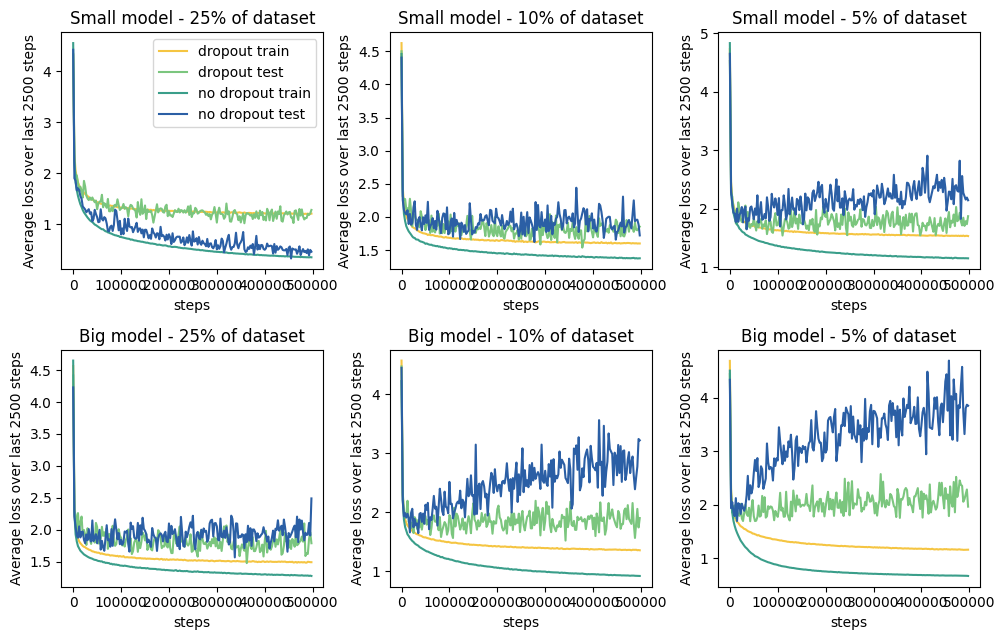

In [ ]:
sizes = [25, 10, 5]
capacity = ["small", "big"]
fig, axs = plt.subplots(2, 3, figsize=(10, 6.5))

for i, cap in enumerate(capacity):
    for j, size in enumerate(sizes):
        df = pd.read_csv(f"{cap}_dropout_{size}.csv")
        x = df["step"]
        ax = axs[i, j]
        ax.plot(x, df["dropout_train"], label="dropout train", color="#F5C542")
        ax.plot(x, df["dropout_test"], label="dropout test", color="#7BC67E")
        ax.plot(x, df["no_dropout_train"], label="no dropout train", color="#3A9E8A")
        ax.plot(x, df["no_dropout_test"], label="no dropout test", color="#2B5FA5")
        ax.set_xlabel("steps")
        ax.set_ylabel("Average loss over last 2500 steps")
        ax.set_title(f"{cap.capitalize()} model - {size}% of dataset")
        if i == 0 and j == 0:
            ax.legend()


plt.tight_layout()

for ax in axs.flat:
    ax.tick_params(axis='x', rotation=45)

plt.show()

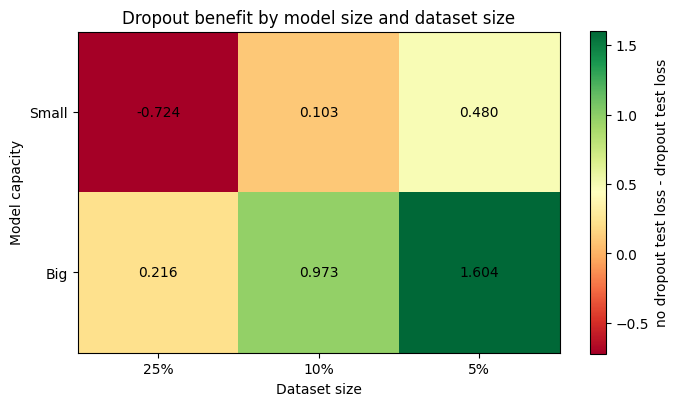

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

sizes = [25, 10, 5]
capacity = ["small", "big"]

diff_matrix = np.zeros((2, 3))

for i, cap in enumerate(capacity):
    for j, size in enumerate(sizes):
        df = pd.read_csv(f"{cap}_dropout_{size}.csv")
        no_dropout_test = df["no_dropout_test"].iloc[-10:].mean()
        dropout_test = df["dropout_test"].iloc[-10:].mean()
        diff_matrix[i, j] = no_dropout_test - dropout_test

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(diff_matrix, cmap="RdYlGn")
ax.set_xticks(range(3))
ax.set_xticklabels([f"{s}%" for s in sizes])
ax.set_yticks(range(2))
ax.set_yticklabels([c.capitalize() for c in capacity])
ax.set_xlabel("Dataset size")
ax.set_ylabel("Model capacity")
plt.colorbar(im, label="no dropout test loss - dropout test loss")

for i in range(2):
    for j in range(3):
        ax.text(j, i, f"{diff_matrix[i,j]:.3f}", ha="center", va="center", color="black")

plt.title("Dropout benefit by model size and dataset size")
plt.tight_layout()
plt.show()